## Setup

In [1]:
%matplotlib inline
from pathlib import Path

import fig_settings as fs
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from pygam import LinearGAM, f, l, s
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import binned_statistic_2d
import pandas as pd
import sys
sys.path.append("../")

from spcg import *

In [2]:
fs.set_colors()
fs.set_fonts()
colors = ["#2d5d83", "#4f9bd9", "#077187", "#3dfaff", "#8b888e"]

In [3]:
DATA_DIR = Path("../figure_data")  # cached data tables (pairs, hops, semantic)
FIGURES_DIR = Path("../figures")
METHOD = "cluster_average"
MODEL_SAFE = "all-MiniLM-L6-v2"
MAX_SHARED_PACKS = 8
NULL_STATISTIC = "interaction"

S_EFF_CAP = 25.0

# Load all dataframes

In [4]:
# This is the dataframe for the raw count of shared SP pairs
df_raw_counts_max8 = pl.read_csv(DATA_DIR / "similarity_vs_raw_overlap_max8_seed16.csv")

# This is the dataframe for the raw count of shared SP pairs, but with a higher cap on the number of shared SPs
df_raw_counts_max25 = pl.read_csv(
    DATA_DIR / "similarity_vs_raw_overlap_max25_seed16.csv"
)

# This is the dataframe for the renormalized count of shared SP pairs.
df_renormalized_counts = pl.read_csv(
    DATA_DIR / "similarity_vs_renormalized_overlap_seed16.csv"
)

# This is the dataframe for the degree-matched null model.
df_null = pl.read_csv(DATA_DIR / "similarity_vs_overlap_null_seed16.csv")

df_null = df_null.filter(pl.col("s_raw") <= MAX_SHARED_PACKS).sort("s_raw")
ms = df_null["s_raw"].to_list()
mv = df_null["mean_cosine"].to_list()

# The null matches the first point of the raw counts, so we add a point at 0 for the null model to match the raw counts.
ms = [0] + ms
mv = [df_raw_counts_max8["mean_cosine"][0]] + mv

df_network_and_sps = pl.read_csv(DATA_DIR / "similarity_vs_renormalized_overlap_and_network_distance_seed16.csv")

df_degrees = pl.read_csv(DATA_DIR / "similarity_vs_degrees_seed16.csv")

df_similarity_vs_degrees = pl.read_csv(DATA_DIR / "similarity_vs_degrees_seed16.csv")

df_similarity_data_vs_hcm_null = pl.read_csv(DATA_DIR / "similarity_vs_overlaps_hcm_null_seed16.csv")

In [5]:
INCLUDE_ZERO = False  # include the n_eff==0 disjoint-baseline pairs?

df_continuous = df_renormalized_counts.clone()

df_continuous = df_continuous.filter(pl.col("s_eff") <= S_EFF_CAP)

cont = df_continuous.select(["s_eff", "cosine"]).drop_nulls()

if not INCLUDE_ZERO:
    cont = cont.filter(pl.col("s_eff") > 0)

x = cont["s_eff"].to_numpy().astype(float)
y = cont["cosine"].to_numpy().astype(float)

# smoothed trend, shared by both plots below
fit = lowess(
    y,
    x,
    frac=0.3,
    it=5,
    delta=0.01 * (x.max() - x.min()),
    return_sorted=True,
)
trend_x, trend_y, trend_lbl = fit[:, 0], fit[:, 1], "LOWESS trend"

# x and y should be 1D numpy arrays
X = x.reshape(-1, 1)

gam = LinearGAM(s(0)).fit(X, y)

# truncate to match the other plot's x-axis range
xx = np.linspace(x.min(), MAX_SHARED_PACKS, 500)
yy = gam.predict(xx)
ci = gam.confidence_intervals(xx, width=0.95)

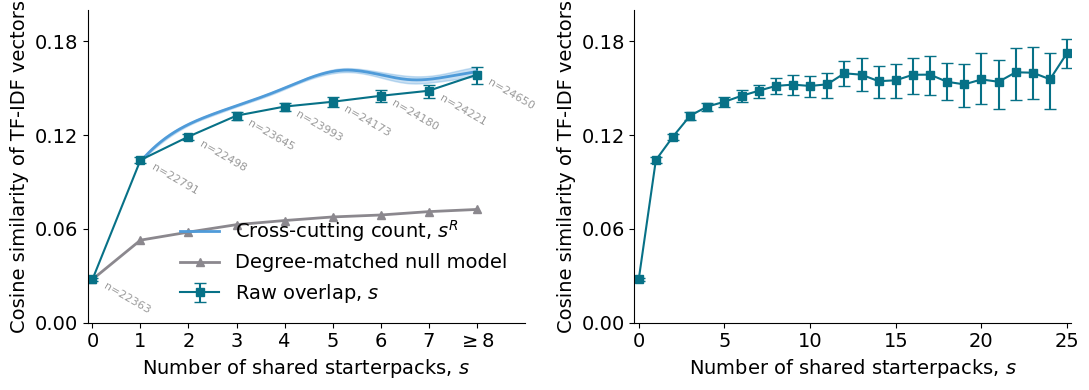

In [6]:
df = df_raw_counts_max8
plt.figure(figsize=(11, 4))
plt.subplot(121)

# plot raw counts
plt.errorbar(
    df["s_raw"],
    df["mean_cosine"],
    yerr=[df["err_low"], df["err_high"]],
    fmt="s-",
    capsize=4,
    color=colors[2],
    ecolor=colors[2],
    linewidth=1.5,
    label=r"Raw overlap, $s$",
)

for r in df.iter_rows(named=True):
    plt.annotate(
        f"n={int(r['count'])}",
        (r["s_raw"], r["mean_cosine"]),
        textcoords="offset points",
        xytext=(25, -25),
        rotation=-30,
        fontsize=8,
        ha="center",
        color="#999999",
    )

plt.plot(xx, yy, lw=2, color=colors[1], label=r"Cross-cutting count, $s^R$")
plt.fill_between(xx, ci[:, 0], ci[:, 1], alpha=0.3, color=colors[1])

plt.plot(ms, mv, "^-", lw=2, color=colors[4], label="Degree-matched null model")

plt.xlim([-0.1, 9])
plt.xticks(range(9), list(range(8)) + [r"$\geq 8$"])

plt.yticks([0, 0.06, 0.12, 0.18])
plt.ylim([0, 0.2])

plt.xlabel(r"Number of shared starterpacks, $s$")
plt.ylabel("Cosine similarity of TF-IDF vectors")
plt.legend(frameon=False)
plt.subplot(122)

df = df_raw_counts_max25
plt.errorbar(
    df["s_raw"],
    df["mean_cosine"],
    yerr=[df["err_low"], df["err_high"]],
    fmt="s-",
    capsize=4,
    color=colors[2],
    ecolor=colors[2],
    linewidth=1.5,
)
plt.xlim([-0.25, 25.25])
plt.yticks([0, 0.06, 0.12, 0.18])
plt.ylim([0, 0.2])

plt.xlabel(r"Number of shared starterpacks, $s$")
plt.ylabel("Cosine similarity of TF-IDF vectors")

sns.despine()
plt.tight_layout()

#plt.savefig(FIGURES_DIR / "similarity_vs_overlap.pdf", bbox_inches="tight", dpi=1000)

## Distribution of shared packs: raw count vs effective number

Shows the distribution of the **raw** number of shared starterpacks and how it **changes** once we discount redundancy with the **effective** number `s_eff` (which is `<= k` for `k` shared packs, and which we refer to as the 'cross-cutting community count'). Two views, one figure each:
- **overlay** of the two distributions (mass shifts down/left as redundant packs collapse), and
- a per-`k` **breakdown** of `s_eff` (how a given raw count spreads into a range of effective distinct packs, sitting below the `s_eff = k` ceiling).

Restricted to pairs that share `>= 1` pack.

In [7]:
def distributionBin(x, B):
    """
    :param x: (list) list of real-valued integers interpreted as the input data sampled from a presumed heavy-tail distribution
    :param B: (positive int) number of log-scaled bins to create a histogram from x

    distributionBin: Tuple, int -> Tuple, Tuple[Float]

    distributionBin takes a list of input data :x: assumed to be sampled from some heavy-tailed distribution and bins in :B: log
    sized bins in such a way that the output function *integrates* to 1. The output is a list of bin-midpoints X and the binned
    estimated distribution values Y.
    """

    xmin = min(x)
    xmax = max(x)

    # creating the B+1 bin edges
    bin_edges = np.logspace(np.log10(xmin), np.log10(xmax), num=B + 1)

    # using numpy's histogram function get distributions
    density, _ = np.histogram(x, bins=bin_edges, density=True)

    # obtaining bin midpoints for cleaner absciss
    log_be = np.log10(bin_edges)
    xout = 10 ** ((log_be[1:] + log_be[:-1]) / 2)

    return xout, density

In [8]:
# processing: raw shared-pack count vs n_eff, for pairs sharing >=1 pack
dd = df_renormalized_counts[["s_raw", "s_eff"]].drop_nans()
dd = dd.filter(pl.col("s_raw") >= 1)
s_raw = dd["s_raw"].to_numpy()
s_eff = dd["s_eff"].to_numpy()
print(
    f"{len(dd):,} pairs (>=1 shared pack); "
    f"raw count in [{s_raw.min():.0f}, {s_raw.max():.0f}] mean={s_raw.mean():.2f} | "
    f"s_eff in [{s_eff.min():.2f}, {s_eff.max():.2f}] mean={s_eff.mean():.2f} | "
    f"mean shrinkage s_eff/k = {(s_eff/np.maximum(s_raw,1)).mean():.2f}"
)

190,151 pairs (>=1 shared pack); raw count in [1, 11528] mean=8.26 | s_eff in [1.00, 2600.43] mean=4.29 | mean shrinkage s_eff/k = 0.69


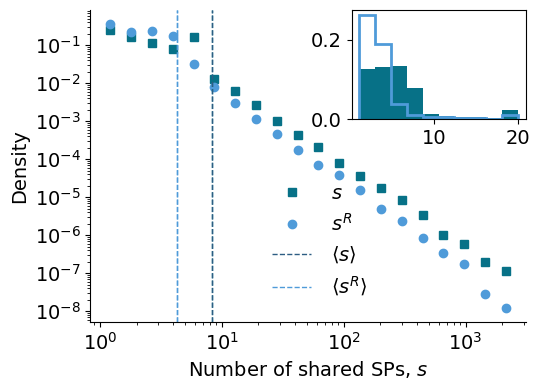

In [9]:
# overlay: raw shared-pack count distribution vs effective (n_eff) distribution
xmax = max(
    int(np.ceil(np.percentile(s_raw, 99))), int(np.ceil(s_eff.max()))
)  # trim long tail
kc = np.clip(s_raw, None, xmax)  # pile the tail into the top bin
nc = np.clip(s_eff, None, xmax)

plt.figure(figsize=(5.5, 4))
bin_means_kc, density_kc = distributionBin(kc, 20)
bin_means_nc, density_nc = distributionBin(nc, 20)
plt.plot(
    bin_means_kc,
    density_kc,
    label=r"$s$",
    marker="s",
    linestyle="None",
    color=colors[2],
)
plt.plot(
    bin_means_nc,
    density_nc,
    label=r"$s^R$",
    marker="o",
    linestyle="None",
    color=colors[1],
)
plt.axvline(s_raw.mean(), color=colors[2], ls="--", lw=1)
plt.axvline(s_eff.mean(), color=colors[1], ls="--", lw=1)

# inset--clipped
ax = plt.gca()
axin = ax.inset_axes([0.6, 0.65, 0.4, 0.35])
clipped_max = 20
kc_clipped = np.clip(s_raw, None, clipped_max)  # pile the tail into the top bin
nc_clipped = np.clip(s_eff, None, clipped_max)
bins_kc_clipped = np.linspace(min(kc_clipped), max(kc_clipped), num=11)
bins_nc_clipped = np.linspace(min(nc_clipped), max(nc_clipped), num=11)
axin.hist(
    kc_clipped,
    bins=bins_kc_clipped,
    density=True,
    histtype="stepfilled",
    color=colors[2],
    label="Raw number of shared SPs",
)
axin.hist(
    nc_clipped,
    bins=bins_nc_clipped,
    density=True,
    histtype="step",
    color=colors[1],
    lw=2,
    label="Cross-cutting community count",
)
plt.axvline(
    s_raw.mean(), color=colors[0], ls="--", lw=1, label=r"$\langle s\rangle$"
)
plt.axvline(
    s_eff.mean(), color=colors[1], ls="--", lw=1, label=r"$\langle s^R \rangle$"
)

plt.xlabel(r"Number of shared SPs, $s$")
plt.ylabel("Density")
plt.legend(frameon=False, handletextpad=1, loc=(0.4, 0.05))
ax.spines[["top", "right"]].set_visible(False)
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
#plt.savefig(FIGURES_DIR / "shared_sp_distribution.pdf", dpi=1000)
plt.show()

In [10]:
print(
    f"The mean effective s is {s_eff.mean():.3f}, the mean of s_raw is {s_raw.mean():.3f}, and the ratio is {s_eff.mean() / s_raw.mean():.3f}"
)

The mean effective s is 4.293, the mean of s_raw is 8.260, and the ratio is 0.520


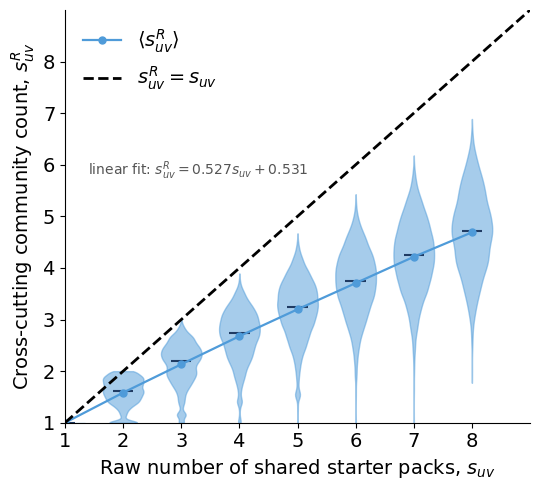

In [12]:
# Per-k breakdown: distribution of s_eff within each raw shared-pack count
# Discard observations with s_raw > MAX_SHARED_PACKS.

# Keep only observations within the plotted range
mask = s_raw <= MAX_SHARED_PACKS
s = s_raw[mask].astype(int)
seff = s_eff[mask]

levels = np.arange(1, MAX_SHARED_PACKS + 1)

# Group s_eff by raw shared-pack count
groups = [seff[s == lvl] for lvl in levels]

# Keep only groups that contain observations
valid = [(lvl, g) for lvl, g in zip(levels, groups) if len(g)]

pos = [lvl for lvl, _ in valid]
data = [g for _, g in valid]
means = [g.mean() for g in data]

plt.figure(figsize=(5.5, 5))
ax = plt.gca()

# Violin plots
parts = ax.violinplot(
    data,
    positions=pos,
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=False,
)

# Style violins
for body in parts["bodies"]:
    body.set_facecolor(colors[1])
    body.set_edgecolor(colors[1])
    body.set_alpha(0.5)

parts["cmedians"].set_color("#1f3b63")
parts["cmedians"].set_linewidth(1.5)

# Mean s_eff
ax.plot(
    pos,
    means,
    "o-",
    color=colors[1],
    lw=1.6,
    ms=5,
    label="$\\langle s^R_{uv} \\rangle$",
)

# Ideal case: every shared pack is distinct
ax.plot(
    [1, MAX_SHARED_PACKS + 1],
    [1, MAX_SHARED_PACKS + 1],
    "k--",
    lw=2,
    label="$s^R_{uv} = s_{uv}$",
)

np.polyfit(levels, means, 1)  # linear fit to the mean s_eff vs s_raw

plt.annotate(
    f"linear fit: $s^R_{{uv}} = {np.polyfit(levels, means, 1)[0]:.3f} s_{{uv}} + {np.polyfit(levels, means, 1)[1]:.3f}$",
    xy=(0.05, 0.6),
    xycoords="axes fraction",
    fontsize=10,
    color="#555555",
)
# Labels
ax.set_xticks(levels)
ax.set_yticks(levels)
ax.set_xticklabels([str(k) for k in levels])

ax.set_xlabel("Raw number of shared starter packs, $s_{uv}$")
ax.set_ylabel("Cross-cutting community count, $s^R_{uv}$")

# Clean up
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.xlim(1, MAX_SHARED_PACKS + 1)
plt.ylim(1, MAX_SHARED_PACKS + 1)
plt.tight_layout()

#plt.savefig(
#    FIGURES_DIR / "shared_sp_distribution_per_s.pdf",
#    dpi=1000,
#    bbox_inches="tight",
#)

plt.show()

# Similarity versus network distance stratified by overlap

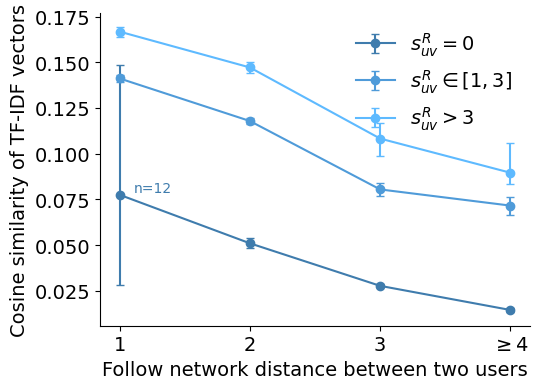

In [13]:
strata = [0, 1, 2]
def scale_hex_color(hex_color, scale_factor):
    """
    Scale a hex color. Use factor < 1 to darken, > 1 to lighten.
    """
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    
    # Clamp values between 0 and 255
    r = max(0, min(255, int(r * scale_factor)))
    g = max(0, min(255, int(g * scale_factor)))
    b = max(0, min(255, int(b * scale_factor)))
    
    return f"#{r:02x}{g:02x}{b:02x}"

s_eff_colors = [scale_hex_color(colors[1], 0.8), scale_hex_color(colors[1], 1.0), scale_hex_color(colors[1], 1.2)]
disp = {
    0: (r"$s_{uv}^R=0$", s_eff_colors[0]),
    1: (r"$s_{uv}^R \in [1,3]$", s_eff_colors[1]),
    2: (r"$s_{uv}^R>3$", s_eff_colors[2]),
}
distances = ["1", "2", "3", "4"]
distance_labels = ["1", "2", "3", r"$\geq 4$"]
xs = np.arange(len(distances))

plt.figure(figsize=(5.5, 4))
ax = plt.gca()
for s in strata:
    label, color = disp[s]
    d = df_network_and_sps.filter(pl.col("s_eff_regime") == s).sort("network_distance")
    y = d["mean_cosine"].to_numpy()
    lo = (d["mean_cosine"] - d["ci_low"]).to_numpy()
    hi = (d["ci_high"] - d["mean_cosine"]).to_numpy()
    ax.errorbar(
        xs, y, yerr=[lo, hi], fmt="o-", capsize=3, color=color, label=label, zorder=3
    )
    if s == 0:  # de-emphasize the n=12 cell
        ax.annotate(
            "n=12",
            (xs[0], y[0]),
            textcoords="offset points",
            xytext=(10, 5),
            color=color,
            ha="left",
            va="center",
        )

ax.set_xticks(xs)
ax.set_xticklabels(distance_labels)
ax.tick_params(axis="y")
ax.set_xlabel(r"Follow network distance between two users")
ax.set_ylabel("Cosine similarity of TF-IDF vectors")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
#plt.savefig(FIGURES_DIR / "similarity_vs_network_distance_stratified.pdf")
plt.show()

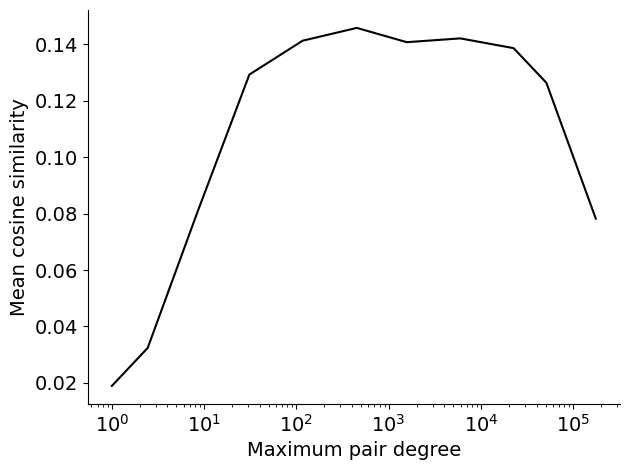

In [14]:
num_bins = 10
bin_edges = np.linspace(df_similarity_vs_degrees["k_v"].min(), df_similarity_vs_degrees["k_v"].max(), num_bins)
bin_edges = np.logspace(np.log10(df_similarity_vs_degrees["k_v"].min()), np.log10(df_similarity_vs_degrees["k_v"].max()), num_bins)

# Assign rows to bins
df = df_similarity_vs_degrees.with_columns(
    pl.col("k_v").cut(breaks=bin_edges, labels=[str(i) for i in range(num_bins + 1)]).alias("bin_index")
)

stats1 = df.group_by("bin_index").agg(
    pl.col("k_v").mean().alias("median_k")
)
stats2 = df.group_by("bin_index").agg(
    pl.col("cosine").mean().alias("median_sim")
)



stats = stats1.join(stats2, on="bin_index").sort(by="median_k")

plt.plot(stats["median_k"], stats["median_sim"], color="black")

plt.xscale("log")
# plt.yscale("log")

plt.xlabel("Maximum pair degree")
plt.ylabel("Mean cosine similarity")

sns.despine()
plt.tight_layout()
#plt.savefig(FIGURES_DIR / "similarity_vs_max_pair_degree.pdf", dpi=1000)
plt.show()

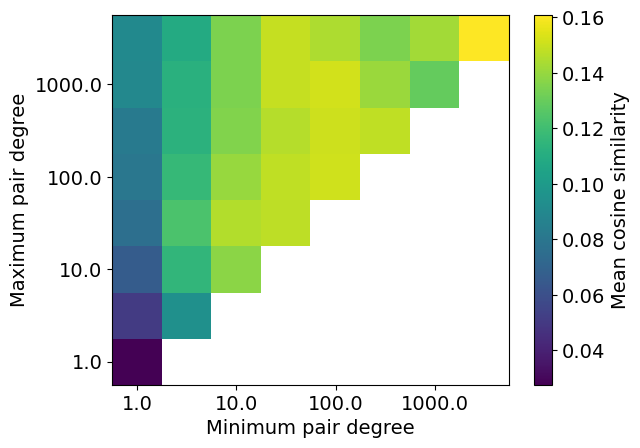

In [55]:
x = df_similarity_vs_degrees["k_u"].to_numpy()
y = df_similarity_vs_degrees["k_v"].to_numpy()
z = df_similarity_vs_degrees["cosine"].to_numpy()

num_bins = 9
x_bins = np.logspace(np.log10(x.min()), round(np.log10(x.max())), num_bins)
#y_bins = np.logspace(np.log10(y.min()), round(np.log10(y.max())), num_bins)

z_mean, x_edges, y_edges, _ = binned_statistic_2d(
    x,
    y,
    z,
    statistic="mean",
    bins=[x_bins, x_bins]
)

plt.figure()
plt.imshow(
    z_mean.T,
    origin="lower",
    aspect="auto",
)

plt.xlabel("Minimum pair degree")
plt.ylabel("Maximum pair degree")

plt.xticks(range(0, num_bins-1, 2), x_bins[::2][:-1])
plt.yticks(range(0, num_bins-1, 2), x_bins[::2][:-1])

plt.colorbar(label="Mean cosine similarity")
plt.savefig(FIGURES_DIR / "similarity_vs_degrees_heatmap.pdf", bbox_inches="tight", dpi=1000)
plt.show()

In [42]:
round(np.log10(x.max()))

4

In [35]:
round(325, -2)

300

In [28]:
x_bins

array([1.00000000e+00, 2.27559059e+00, 5.17831254e+00, 1.17837193e+01,
       2.68149208e+01, 6.10197814e+01, 1.38856041e+02, 3.15979500e+02,
       7.19039976e+02, 1.63624061e+03, 3.72341373e+03, 8.47296525e+03,
       1.92810000e+04])

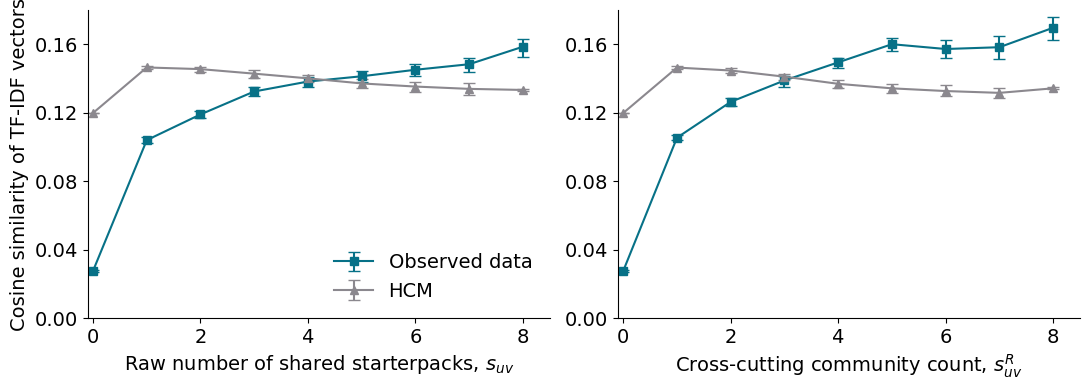

In [16]:
plt.figure(figsize=(11, 4))

plt.subplot(121)
# plot raw counts
raw_counts = df_similarity_data_vs_hcm_null.filter(pl.col("overlap_kind") == "s_raw")
plt.errorbar(
    raw_counts["bin"],
    raw_counts["observed_mean_cosine"],
    yerr=[raw_counts["observed_err_low"], raw_counts["observed_err_high"]],
    fmt="s-",
    capsize=4,
    color=colors[2],
    ecolor=colors[2],
    linewidth=1.5,
    label="Observed data",
)

plt.errorbar(
    raw_counts["bin"],
    raw_counts["null_mean_cosine"],
    yerr=[raw_counts["null_err_low"], raw_counts["null_err_high"]],
    fmt="^-",
    capsize=4,
    color=colors[4],
    ecolor=colors[4],
    linewidth=1.5,
    label="HCM",
)

plt.legend(frameon=False)
plt.xlim([-0.1, 8.5])
plt.ylim([0, 0.18])
plt.yticks([0, 0.04, 0.08, 0.12, 0.16])
plt.ylabel("Cosine similarity of TF-IDF vectors")
plt.xlabel(r"Raw number of shared starterpacks, $s_{uv}$")

plt.subplot(122)
# plot raw counts
raw_counts = df_similarity_data_vs_hcm_null.filter(pl.col("overlap_kind") == "s_eff")
plt.errorbar(
    raw_counts["bin"],
    raw_counts["observed_mean_cosine"],
    yerr=[raw_counts["observed_err_low"], raw_counts["observed_err_high"]],
    fmt="s-",
    capsize=4,
    color=colors[2],
    ecolor=colors[2],
    linewidth=1.5,
    label="Observed data",
)

plt.errorbar(
    raw_counts["bin"],
    raw_counts["null_mean_cosine"],
    yerr=[raw_counts["null_err_low"], raw_counts["null_err_high"]],
    fmt="^-",
    capsize=4,
    color=colors[4],
    ecolor=colors[4],
    linewidth=1.5,
    label="HCM",
)

plt.xlim([-0.1, 8.5])
plt.ylim([0, 0.18])
plt.yticks([0, 0.04, 0.08, 0.12, 0.16])
plt.xlabel(r"Cross-cutting community count, $s_{uv}^R$")

sns.despine()
plt.tight_layout()
#plt.savefig(FIGURES_DIR / "data_vs_hcm.pdf", dpi=1000)

degree_populations_seed16.npz:
  deg_bin0   -> uniform_s0   n=    44,726  k in [1, 175159]  median=2
  deg_null   -> config_null  n=   511,564  k in [1, 175159]  median=586
  deg_bin1   -> observed_s1  n=   380,302  k in [2, 175159]  median=73


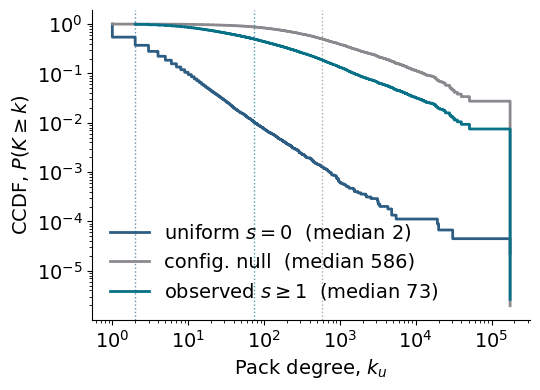

In [19]:
B1_NPZ = Path("/scratch/xee6vz/study_data/degree_diagnostic/degree_populations_seed16.npz")
 
_NPZ_KEYS = {
    "uniform_s0": "deg_bin0",
    "config_null": "deg_null",
    "observed_s1": "deg_bin1",
}
 
 
def load_degree_populations(path=None):
    path = B1_NPZ if path is None else Path(path)
    f = np.load(path, allow_pickle=False)
 
    absent = [k for k in _NPZ_KEYS.values() if k not in f.files]
    if absent:
        raise KeyError(f"{path.name} is missing {absent}; keys present: {f.files}")
 
    out = {}
    print(f"{path.name}:")
    for pop, key in _NPZ_KEYS.items():
        v = np.asarray(f[key], dtype=float)
        out[pop] = v
        print(f"  {key:<10} -> {pop:<12} n={v.size:>10,}  "
              f"k in [{v.min():.0f}, {v.max():.0f}]  median={np.median(v):.0f}")
    return out
 
 
degree_populations = load_degree_populations()

POPULATIONS = [
    ("uniform_s0", r"uniform $s{=}0$", colors[0]),
    ("config_null", "config. null", colors[4]),
    ("observed_s1", r"observed $s{\geq}1$", colors[2]),
]
 
 
def _ccdf(v):
    """P(K >= k), endpoint-weighted.  Matches the original cell exactly."""
    v = np.sort(v[v > 0])
    return v, 1.0 - np.arange(len(v)) / len(v)
 
 
fig, ax = plt.subplots(figsize=(5.5, 4))
 
medians = {}
for key, label, color in POPULATIONS:
    v = degree_populations[key]
    vx, vy = _ccdf(v)
    med = float(np.median(v))
    medians[key] = med
    ax.step(vx, vy, where="post", color=color, lw=2,
            label=f"{label}  (median {med:.0f})")
    ax.axvline(med, color=color, ls=":", lw=1, alpha=0.7)
 
ax.set_xscale("log")
ax.set_yscale("log")  # original had linear y; drop this line to match it exactly
ax.set_xlabel(r"Pack degree, $k_u$")
ax.set_ylabel(r"CCDF, $P(K \geq k)$")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
 
plt.tight_layout()
#plt.savefig(FIGURES_DIR / "degree_distributions_by_bin.pdf", dpi=1000,
#            bbox_inches="tight")
plt.show()

sem_data: 190,151 rows; columns: ['shared_packs', 'n_eff', 'cosine']
user identifiers present : False  -- bootstrap must fall back to pair-level

pairs in the grid (s in 2..8): 146,377 of 190,151 shared-pack pairs

CELL COUNTS -- fine grid (6 columns):
neff_bin      <=1.5  (1.5, 2.5]  (2.5, 3.5]  (3.5, 4.5]  (4.5,5.5]  >5.5
shared_packs                                                            
2              7792       14706           0           0          0     0
3              1979       17136        4530           0          0     0
4               681        7255       15426         631          0     0
5               126        2677       13450        7889         31     0
6                47         857        7767       12997       2512     0
7                30         299        3465       11663       8157   607
8                 0          12         235        1222       1597   601
fine  : 26/30 occupied cells have n >= 100 (87%)
coarse: 24/28 occupied cells have n >= 10

/tmp/ipykernel_929125/1564377175.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels())


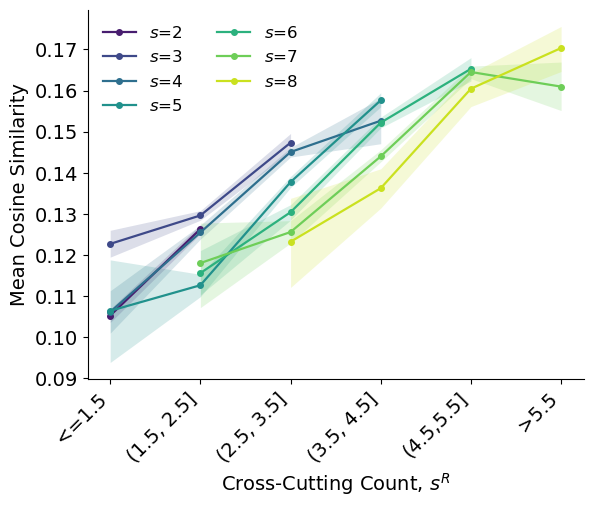

In [18]:
XC_SEED = 16
XC_NBOOT = 500
XC_MIN_N = 100      # cells thinner than this are masked (the n=12 episode)
XC_FS = 16

XC_S_ROWS = list(range(2, 9))
XC_EDGES = [1.0, 1.5, 2.5, 3.5, 4.5, 5.5, np.inf]
XC_LABELS = ["<=1.5", "(1.5, 2.5]", "(2.5, 3.5]", "(3.5, 4.5]", "(4.5,5.5]", ">5.5"]
XC_COARSE_EDGES = [1.0, 1.5, 2.5, 3.5, 4.5, np.inf]
XC_COARSE_LABELS = ["<=1.5", "1.5-2.5", "2.5-3.5", "3.5-4.5", ">4.5"]

# --- source table, renamed to the original's schema -------------------------
_user_pairs = [("user_a", "user_b"), ("uid_a", "uid_b"), ("u", "v"),
               ("did_a", "did_b"), ("did_u", "did_v")]
_cols = set(df_renormalized_counts.columns)
XC_UCOLS = next((p for p in _user_pairs if set(p) <= _cols), None)
XC_HAVE_USERS = XC_UCOLS is not None

_src = (
    df_renormalized_counts
    .select(["s_raw", "s_eff", "cosine"] + (list(XC_UCOLS) if XC_HAVE_USERS else []))
    .drop_nulls(subset=["s_raw", "s_eff", "cosine"])
    .filter(pl.col("s_eff").is_not_nan() & pl.col("cosine").is_not_nan())
)
# built column-wise from numpy rather than .to_pandas(), which needs pyarrow
sem_data = pd.DataFrame({
    "shared_packs": _src["s_raw"].to_numpy(),
    "n_eff": _src["s_eff"].to_numpy(),
    "cosine": _src["cosine"].to_numpy(),
})
if XC_HAVE_USERS:
    sem_data["user_a"] = _src[XC_UCOLS[0]].to_numpy()
    sem_data["user_b"] = _src[XC_UCOLS[1]].to_numpy()
sem_data["shared_packs"] = sem_data["shared_packs"].astype(int)
CG_COL = "n_eff"

print(f"sem_data: {len(sem_data):,} rows; columns: {list(sem_data.columns)}")
print(f"user identifiers present : {XC_HAVE_USERS}"
      + (f"  (from {XC_UCOLS[0]}/{XC_UCOLS[1]})" if XC_HAVE_USERS
         else "  -- bootstrap must fall back to pair-level"))


def xc_build_grid(df, edges, labels):
    """Pairs with s in XC_S_ROWS, tagged with their (s, s^R-bin) cell."""
    d = df[df["shared_packs"].isin(XC_S_ROWS)].copy()
    d["neff_bin"] = pd.cut(d[CG_COL], bins=edges, labels=labels,
                           right=True, include_lowest=True)
    d = d[d["neff_bin"].notna()].copy()
    d["cell"] = d["shared_packs"].astype(str) + "|" + d["neff_bin"].astype(str)
    return d


def xc_counts(d, labels):
    return d.pivot_table(index="shared_packs", columns="neff_bin", values="cosine",
                         aggfunc="size", observed=False
                         ).reindex(index=XC_S_ROWS, columns=labels)


xc = xc_build_grid(sem_data, XC_EDGES, XC_LABELS)
cnt_fine = xc_counts(xc, XC_LABELS)
cnt_coarse = xc_counts(xc_build_grid(sem_data, XC_COARSE_EDGES, XC_COARSE_LABELS),
                       XC_COARSE_LABELS)

print(f"\npairs in the grid (s in {XC_S_ROWS[0]}..{XC_S_ROWS[-1]}): {len(xc):,} "
      f"of {int((sem_data.shared_packs >= 1).sum()):,} shared-pack pairs")
print(f"\nCELL COUNTS -- fine grid ({len(XC_LABELS)} columns):")
print(cnt_fine.fillna(0).astype(int).to_string())


def xc_viable(cnt):
    reach = cnt.notna() & (cnt > 0)
    return int((cnt.fillna(0) >= XC_MIN_N).sum().sum()), int(reach.sum().sum())


for nm_, c in (("fine", cnt_fine), ("coarse", cnt_coarse)):
    ok, reach = xc_viable(c)
    print(f"{nm_:6s}: {ok}/{reach} occupied cells have n >= {XC_MIN_N} "
          f"({ok / max(reach, 1):.0%})")

# Decision on COUNTS ONLY -- never on the effect.
ok_f, reach_f = xc_viable(cnt_fine)
XC_USE_COARSE = (ok_f / max(reach_f, 1)) < 0.60
if XC_USE_COARSE:
    XC_EDGES, XC_LABELS = XC_COARSE_EDGES, XC_COARSE_LABELS
    xc = xc_build_grid(sem_data, XC_EDGES, XC_LABELS)
print(f"--> using the {'COARSE' if XC_USE_COARSE else 'FINE'} grid "
      "(decided on cell counts alone, before any cosine was looked at).")
XC_COUNTS = xc_counts(xc, XC_LABELS)


def xc_cluster_boot(d, value_col="cosine", cell_col="cell",
                    n_boot=XC_NBOOT, seed=XC_SEED):
    """-> (levels, boot[n_boot, n_cells], point means, counts)."""
    if len(d) == 0:
        return (np.array([]), np.zeros((n_boot, 0)),
                np.array([]), np.array([], dtype=int))
    vals = d[value_col].to_numpy(float)
    codes, levels = pd.factorize(d[cell_col], sort=True)
    K = len(levels)
    rng = np.random.default_rng(seed)
    boot = np.full((n_boot, K), np.nan)

    if XC_HAVE_USERS:
        users = pd.unique(pd.concat([d["user_a"], d["user_b"]]))
        uidx = {u: i for i, u in enumerate(users)}
        a = d["user_a"].map(uidx).to_numpy(dtype=int)
        b = d["user_b"].map(uidx).to_numpy(dtype=int)
        n_users = len(users)
        for i in range(n_boot):
            m = np.bincount(rng.integers(0, n_users, size=n_users), minlength=n_users)
            w = (m[a] * m[b]).astype(float)
            num = np.bincount(codes, weights=w * vals, minlength=K)
            den = np.bincount(codes, weights=w, minlength=K)
            with np.errstate(invalid="ignore", divide="ignore"):
                boot[i] = np.where(den > 0, num / den, np.nan)
    else:  # PAIR-LEVEL fallback -- not clustered
        n = len(d)
        for i in range(n_boot):
            idx = rng.integers(0, n, size=n)
            c, v = codes[idx], vals[idx]
            den = np.bincount(c, minlength=K).astype(float)
            num = np.bincount(c, weights=v, minlength=K)
            with np.errstate(invalid="ignore", divide="ignore"):
                boot[i] = np.where(den > 0, num / den, np.nan)

    mean = np.array([vals[codes == k].mean() if (codes == k).any() else np.nan
                     for k in range(K)])
    return levels, boot, mean, np.bincount(codes, minlength=K)


def xc_matrix(levels, values, labels=None):
    labels = labels or XC_LABELS
    M = pd.DataFrame(np.nan, index=XC_S_ROWS, columns=labels, dtype=float)
    for lv, v in zip(levels, values):
        s_, b_ = lv.split("|", 1)
        M.loc[int(s_), b_] = v
    return M


XC_BOOT_KIND = ("user-clustered (resample users, weight pairs by m_u*m_v)"
                if XC_HAVE_USERS
                else "PAIR-LEVEL (NOT clustered -- intervals are too narrow)")
print(f"\nbootstrap: {XC_NBOOT} resamples, seed {XC_SEED}, {XC_BOOT_KIND}")

xc_levels, xc_boot, xc_mean, xc_n = xc_cluster_boot(xc, "cosine")
XC_MEAN = xc_matrix(xc_levels, xc_mean)
XC_CI_LO = xc_matrix(xc_levels, np.nanpercentile(xc_boot, 2.5, axis=0))
XC_CI_HI = xc_matrix(xc_levels, np.nanpercentile(xc_boot, 97.5, axis=0))
XC_N = xc_matrix(xc_levels, xc_n.astype(float))
XC_MASK = XC_N.fillna(0) < XC_MIN_N      # True = too thin to read

print(f"\nmean cosine per cell (cells with n < {XC_MIN_N} are masked in the figure):")
print(XC_MEAN.round(4).to_string())
print(f"\nmasked (thin) cells: {int(XC_MASK.sum().sum())} of "
      f"{int((XC_N.fillna(0) > 0).sum().sum())} occupied")

# --- the figure (cell 114, verbatim) ----------------------------------------
fig, ax = plt.subplots()
cols = plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(XC_S_ROWS)))
x = np.arange(len(XC_LABELS))
for c, s_ in zip(cols, XC_S_ROWS):
    m = XC_MEAN.loc[s_].mask(XC_MASK.loc[s_]).to_numpy(float)
    lo = XC_CI_LO.loc[s_].mask(XC_MASK.loc[s_]).to_numpy(float)
    hi = XC_CI_HI.loc[s_].mask(XC_MASK.loc[s_]).to_numpy(float)
    ok = np.isfinite(m)
    if ok.sum() < 2:
        continue
    ax.plot(x[ok], m[ok], "o-", color=c, lw=1.6, ms=4, label=f"$s$={s_}")
    ax.fill_between(x[ok], lo[ok], hi[ok], color=c, alpha=0.18, lw=0)
ax.set_xticks(x, XC_LABELS, rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels())
ax.set_xlabel(r"Cross-Cutting Count, $s^R$")
ax.set_ylabel("Mean Cosine Similarity")
ax.legend(frameon=False, fontsize=XC_FS - 4, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
#fig.savefig(FIGURES_DIR / "sR_curves.pdf", dpi=200, bbox_inches="tight")
plt.show()